# Simulate populations with spontaneus creation
## Part 5

In the previous notebook, we updated the simulation to record the age of death for individuals, and we graphed out the result for 1,000 time steps. We noted the general trend of survival - most cells die young, fewer and fewer survive as age increases. However, we also noted a lot of variation in the sample data. We want to be able to draw accurate conclusions about the life span of the protocells in our simulation, so let's improve our empirical data by running the simulation for much longer, say 100,000 periods.

The following cells of code are taken exactly as they were from part 4.

In [1]:
# Import required modules
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
import random
import collections

In [2]:
def trial(chance):
    """ Returns the boolean outcome of a trial given it's chance of success."""

    return random.random() <= chance


class entity():
    """ The entity object represents a live entity."""
    
    def __init__(self):
        self.period = 0
    
    def __repr__(self):
        return str(self.period)

    def __call__(self):
        self.period += 1
        return self


class environment():
    """ The environment tracks the population and parameters of the simulation."""

    def __init__(self, birth_rate, death_chance):
        self.birth_rate = birth_rate
        self.death_chance = death_chance
        self.population = []
        self.history = []
        self.mortuary = collections.Counter()

    def __call__(self):

        survive, expire = [], []
        for e in self.population:
            if trial(self.death_chance):
               expire.append(e.period) 
            else:
                survive.append(e())
        
        self.population = survive
        self.population.append(entity())
        self.mortuary.update(expire)
        self.history.append(len(self.population))

In [3]:
def run_sim(birth_rate, death_chance, n_periods):
    """ Run simulation of environment n times and plot the result"""

    # Set up plots.
    fig, ax = plt.subplots(1, 3, figsize=(24,5))

    # Run simulation n times.
    env = environment(birth_rate, death_chance)
    for period in range(0, n_periods):
        env()
    history = env.history
    mortuary = tuple(env.mortuary.elements())

    # Set plot properties.
    ax[0].set(
        title=f"Population Simulation Outcome ({n_periods} Periods)",
        xlabel="Periods",
        ylabel="Population",
        xlim=(0, n_periods)
    )
    ax[1].set(
        title=f"Age at Time of Expiration Histogram (10 bins)",
        xlabel="Age (Periods)",
        ylabel="Frequency",
        xlim=(1, max(mortuary))
    )
    ax[2].set(
        title=f"Age at Time of Expiration Frequency Plot",
        xlabel="Age (Periods)",
        ylabel="Frequency",
        xlim=(1, max(mortuary))
    )

    # Line graph of population over time.
    ax[0].plot(history, color=[.5, .5, .5, .5])

    # Frequency bar chart of population age at expiration of entity.
    ax[1].hist(mortuary, 10)

    # Frequency plot of population age at expiration of entity.
    ax[2].hist(mortuary, max(mortuary))

    return mortuary

## Run the Simulation for 100,000 Periods

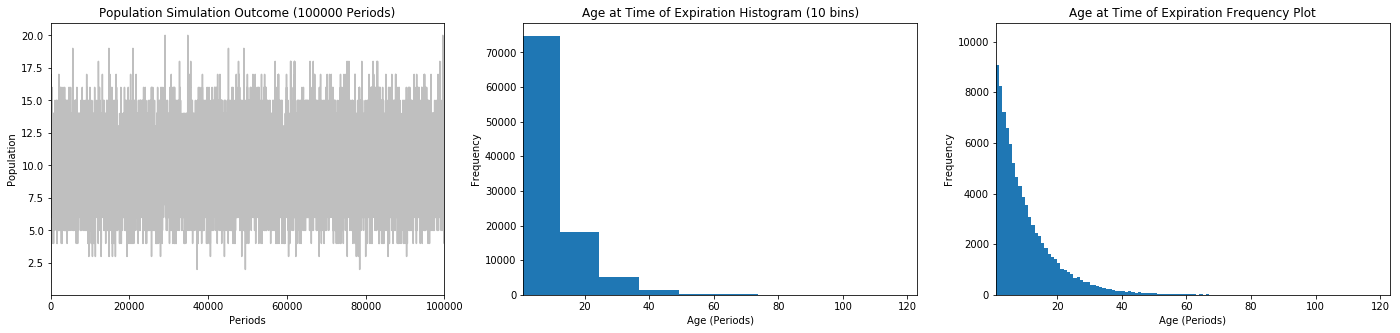

In [15]:
birth_rate = 1
death_chance = 0.1
n_periods = 100000

mortuary = run_sim(birth_rate, death_chance, n_periods)

As you can see, with the larger sample size of 100,000 periods, the Frequency Plot forms a much smoother curve. 

From these empirical observations we can easily calculate the chances of a single protocell surviving past a certain age as the fraction of the overall population that survived past that age. 

In [16]:
mortuary_arr = np.array(mortuary)
total_mortuary = mortuary_arr.size

# Survival chances around 1
p_equal5 = (mortuary_arr[mortuary_arr == 5].size / total_mortuary)
p_greater5 = (mortuary_arr[mortuary_arr > 5].size / total_mortuary)
p_lessequal5 =  (mortuary_arr[mortuary_arr <= 5].size / total_mortuary)

print(f"P(Age == 5)  = {p_equal5:>6.1%}")
print(f"P(Age <= 5)  = {p_lessequal5:>6.1%}")
print(f"P(Age >  5)  = {p_greater5:>6.1%}\n")

# Survival chances around 40
p_equal40 = (mortuary_arr[mortuary_arr == 40].size / total_mortuary)
p_greater40 =  (mortuary_arr[mortuary_arr > 40].size/ total_mortuary)
p_lessequal40 = (mortuary_arr[mortuary_arr <= 40].size / total_mortuary)

print(f"P(Age == 40) = {p_equal40:>6.1%}")
print(f"P(Age <= 40) = {p_lessequal40:6.1%}")
print(f"P(Age >  40) = {p_greater40:>6.1%}")


P(Age == 5)  =   6.0%
P(Age <= 5)  =  47.3%
P(Age >  5)  =  52.7%

P(Age == 40) =   0.2%
P(Age <= 40) =  98.7%
P(Age >  40) =   1.3%


Above, I printed out the probabiliy of a protocell living to be exactly 5, less-than-or-equal to 5, and greater than 5 periods old. I have done the same for age 40.

It turns out that these survival probabilities are easily calculated. All we need to do is calculate the probability of an individual protocell surviving $p-1$ time periods, and then expiring on the final period $p$. The probability of death $P(D)$ is given by `death_chance`, which is 0.1 in our simulation. The probability of surviving $P(S)$ is $1-P(D)$. The probability of multiple events occuring together can be calculated by multiplying the probability of the outcomes together. Knowing this, we can create a function that gives us the probability of surviving exactly to period $p$.

$$ P(Survive\ Exactly\  to\ p)= (1-P(D))^{p-1}\cdot P(D) $$

To find the probability of surviving at least $p$ periods, we can iterate from 1 to $p$ and sum the result.

$$ P(Survive \ At\ Least\ to\ p)= \sum_{p=1}^p (1-P(D))^{p-1}\cdot P(D) $$

And to find the probability of surviving longer than $p$ periods, we can just subract the previous function from 1.

$$ P(Survive\ More\ Than \ p)= 1 - \sum_{p=1}^p (1-P(D))^{p-1}\cdot P(D) $$

Let's recalculate the probabilites we estimated from the empirical data collected from our simulation using this analytical model and see how it does.

In [17]:
def survive_exactly(death_chance, p):
    ''' Probability of surviving exactly to time step p given a constant 
        death_chance independent at each step.'''
        
    return (1-death_chance)**(p-1)*death_chance


In [18]:
# Survival chances around 1
p_equal5 = survive_exactly(death_chance, 5)
p_greater5 =  1 - sum(survive_exactly(death_chance, p) for p in range(1,6))
p_lessequal5 =  sum(survive_exactly(death_chance, p) for p in range(1,6))

print(f"P(Age == 5)  = {p_equal5:>6.1%}")
print(f"P(Age <= 5)  = {p_lessequal5:>6.1%}")
print(f"P(Age >  5)  = {p_greater5:>6.1%}\n")

# Survival chances around 40
p_equal40 = survive_exactly(death_chance, 40)
p_greater40 =  1 - sum(survive_exactly(death_chance, p) for p in range(1,41))
p_lessequal40 = sum(survive_exactly(death_chance, p) for p in range(1,41))

print(f"P(Age == 40) = {p_equal40:>6.1%}")
print(f"P(Age <= 40) = {p_lessequal40:6.1%}")
print(f"P(Age >  40) = {p_greater40:>6.1%}")

P(Age == 5)  =   6.6%
P(Age <= 5)  =  41.0%
P(Age >  5)  =  59.0%

P(Age == 40) =   0.2%
P(Age <= 40) =  98.5%
P(Age >  40) =   1.5%


As you can see, the results are spot on, confirming the analytical model is correct. In fact, the analytical model provides us with a precise estimate, whereas the simluation even with 100,000 samples still has some error due to variation. 

Let's see the analytical model graphed out on top of the empirical data generated from the simulation.

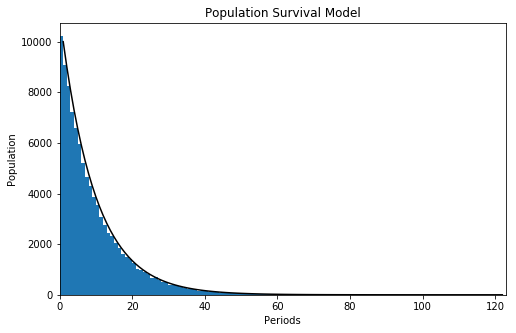

In [19]:
p_survive = [(((1-death_chance)**(x-1))*death_chance)*100000 for x in range(1, max(mortuary))]

fig, ax = plt.subplots(figsize=(8,5))
ax.set(
    title=f"Population Survival Model",
    xlabel="Periods",
    ylabel="Population",
    xlim=(0, max(mortuary))
)
ax.plot(range(1, max(mortuary)), p_survive, color='k')
ax.hist(mortuary, max(mortuary))
plt.show()

### Conclusion

The line generated by the analytical model matches the simulation exactly. This function allows us to accurately calculate the probability of survival of any individual protocell or a total population of protocells with ease. Next, let's see if we can figure out the function that models the growth of the population over time.